<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

Q1. (Loading the Dataset)

In [4]:
df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text","emotions"]
)
df.head(10)

,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [5]:
df.shape

(16000, 2)

In [6]:
df.isnull().sum()

,0
text,0
emotions,0


Q2. (Exploring Target Labels)

In [7]:
df["emotions"].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [8]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["emotions"])

In [9]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [10]:
df.head()

,text,emotions,label
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


Q3. (Lowercasing)

In [11]:
df["text"].head()

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [12]:
df["text"] = df["text"].str.lower()

In [13]:
df["text"].head()

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


Lowercasing converts all text to lowercase, reducing duplicate words like "Happy" and "happy", improving consistency in NLP processing.

Q4. (Removing Punctuation)

In [14]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

df["text"] = df["text"].apply(remove_punctuation)

In [15]:
before = pd.read_csv("train.txt", sep=";", names=["text","emotions"])

for i in range(5):
    print("Before :", before["text"][i])
    print("After  :", df["text"][i])
    print()

Before : i didnt feel humiliated
After  : i didnt feel humiliated

Before : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After  : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Before : im grabbing a minute to post i feel greedy wrong
After  : im grabbing a minute to post i feel greedy wrong

Before : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After  : i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Before : i am feeling grouchy
After  : i am feeling grouchy



Q5. (Removing Numbers)

In [16]:
import re

def remove_numbers(text):
    return re.sub(r"\d+", "", text)

df["text"] = df["text"].apply(remove_numbers)

In [17]:
for i in range(5):
    print(df["text"][i])

i didnt feel humiliated
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
im grabbing a minute to post i feel greedy wrong
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
i am feeling grouchy


Q6. (Removing Emojis & Special Characters)

In [18]:
def remove_emojis(text):
    return text.encode("ascii", "ignore").decode()

df["text"] = df["text"].apply(remove_emojis)

In [19]:
df["text"].head()

,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


Q7. (Removing Stopwords)

In [20]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [22]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["text"] = df["text"].apply(remove_stopwords)

In [23]:
df["text"].head()

,text
0,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy


Q8. (Complete Text Cleaning Pipeline)

In [24]:
import string
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()                                      # Lowercase
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    text = re.sub(r"\d+", "", text)                          # Remove numbers
    text = text.encode("ascii", "ignore").decode()           # Remove emojis
    text = " ".join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

In [25]:
df["cleaned_text"] = df["text"].apply(clean_text)

In [26]:
df[["text", "cleaned_text"]].head(10)

,text,cleaned_text
0,didnt feel humiliated,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy,feeling grouchy
5,ive feeling little burdened lately wasnt sure,ive feeling little burdened lately wasnt sure
6,ive taking milligrams times recommended amount...,ive taking milligrams times recommended amount...
7,feel confused life teenager jaded year old man,feel confused life teenager jaded year old man
8,petronas years feel petronas performed well ma...,petronas years feel petronas performed well ma...
9,feel romantic,feel romantic


Q9. (Text Length Analysis)

In [27]:
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

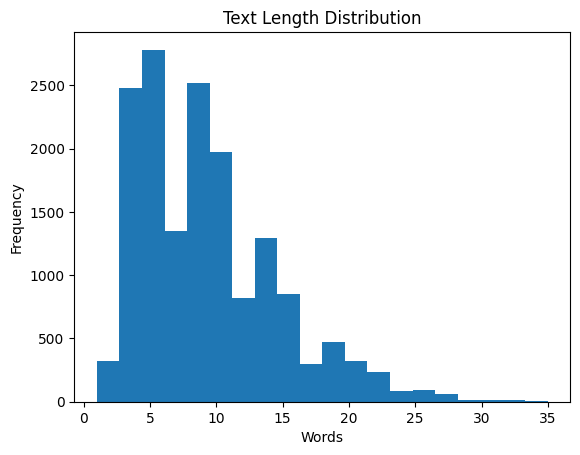

In [28]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [29]:
print("Average:", df["text_length"].mean())
print("Minimum:", df["text_length"].min())
print("Maximum:", df["text_length"].max())

Average: 9.3530625
Minimum: 1
Maximum: 35


Observations :
Most texts have short to medium length.
Cleaning removed unnecessary words and symbols.
The dataset is ready for NLP model training.

Q10. (Mini Project – Full Preprocessing Pipeline)

In [30]:
import pandas as pd

df = pd.read_csv("train.txt", sep=";", names=["text","emotions"])

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label"] = le.fit_transform(df["emotions"])

In [32]:
import string
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.encode("ascii", "ignore").decode()
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

df["cleaned_text"] = df["text"].apply(clean_text)

In [33]:
df.to_csv("cleaned_emotions.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [34]:
print(df["emotions"].value_counts())

emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
